# Lifetime


In [2]:
import numpy as np
import xarray as xr 
import matplotlib.pyplot as plt
import scipy.signal as signal

import cartopy
import cartopy.crs as ccrs
import cartopy.feature       as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

import netCDF4 as nc
import os
import matplotlib.dates as mdates

# CARTHE:

In [3]:
rootdir = '/Users/Gomez023/Postdoc/data/'
savedir = rootdir + 'FaST-SWOT/drifters/'

In [4]:
!ls /Users/Gomez023/Postdoc/data/FaST-SWOT/drifters/CARTHE/L0_SOCIB/

CARTHE_4694040.nc CARTHE_4694193.nc CARTHE_4694206.nc CARTHE_4694473.nc
CARTHE_4694103.nc CARTHE_4694198.nc CARTHE_4694223.nc CARTHE_4694474.nc
CARTHE_4694122.nc CARTHE_4694199.nc CARTHE_4694458.nc CARTHE_4694475.nc
CARTHE_4694188.nc CARTHE_4694201.nc CARTHE_4694461.nc CARTHE_4694476.nc
CARTHE_4694189.nc CARTHE_4694203.nc CARTHE_4694462.nc CARTHE_4695850.nc


In [5]:
carthe_L0 = '/Users/Gomez023/Postdoc/data/FaST-SWOT/drifters/CARTHE/L0_SOCIB/'

In [6]:
from glob import glob
myfiles_C_L0 = sorted(glob(carthe_L0 + '**.nc')) #[1-3]


In [7]:
# Function to read NetCDF files and extract start and end dates for each trajectory
def get_trajectory_dates(netcdf_files):

    lifetimes = []
    for file in netcdf_files:
        ds = xr.open_dataset(file)
        # print(ds.attrs['instrument_serial'])
        # --> done to check L0 SCB and L1 IME drifter order correspond
        times = ds['time'].values
        start_date = np.min(times)
        end_date = np.max(times)
        lifetime = end_date - start_date
        lifetime_days = lifetime / np.timedelta64(1, 'D')  # Convert to days as float
        # lifetime_days = lifetime.astype('timedelta64[D]').astype(float)  # Convert to days (rounds up to integer)
        lifetimes.append(lifetime_days)
        ds.close()

    return lifetimes

In [8]:
lifetimes_C_L0 = get_trajectory_dates(myfiles_C_L0)

In [9]:
len(lifetimes_C_L0)

20

In [10]:
# Extract filenames without extensions to use as trajectory names
trajectory_names_C_L0 = [os.path.splitext(os.path.basename(file))[0] for file in myfiles_C_L0]
trajectory_names_C_L0


['CARTHE_4694040',
 'CARTHE_4694103',
 'CARTHE_4694122',
 'CARTHE_4694188',
 'CARTHE_4694189',
 'CARTHE_4694193',
 'CARTHE_4694198',
 'CARTHE_4694199',
 'CARTHE_4694201',
 'CARTHE_4694203',
 'CARTHE_4694206',
 'CARTHE_4694223',
 'CARTHE_4694458',
 'CARTHE_4694461',
 'CARTHE_4694462',
 'CARTHE_4694473',
 'CARTHE_4694474',
 'CARTHE_4694475',
 'CARTHE_4694476',
 'CARTHE_4695850']

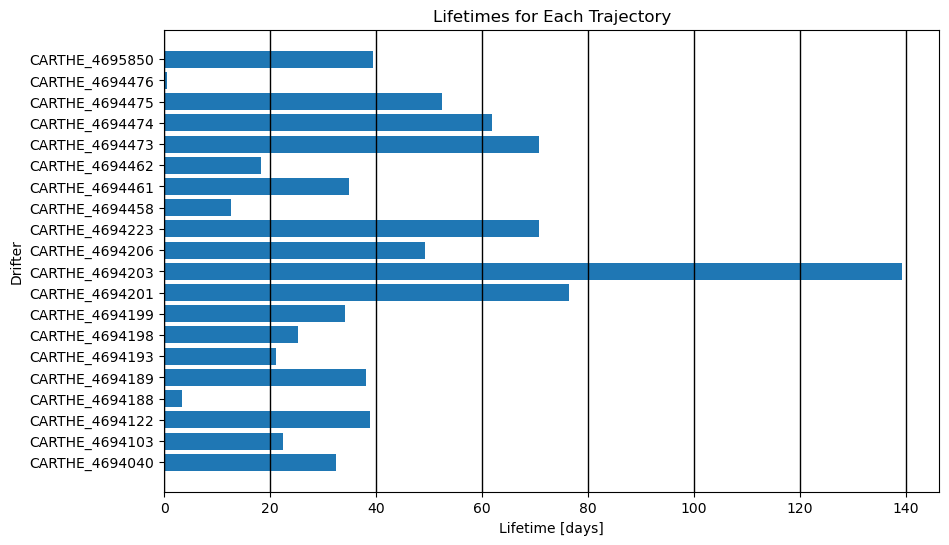

In [11]:
# Create the plot with bars showing the date ranges
plt.figure(figsize=(10, 6))

# Plot each trajectory as a horizontal bar
for ii, lifetime in enumerate(lifetimes_C_L0):
    plt.barh(trajectory_names_C_L0[ii], lifetime, color='C0', align='center') #, alpha=0.5)

# Format the x-axis to show dates properly
ax = plt.gca()

# plt.grid()
# Display grid lines for better visualization
ax.grid(True, which='major', axis='x', color='black', linestyle='-', linewidth=1)
ax.grid(True, which='minor', axis='x', color='grey', linestyle='-', linewidth=0.5)

plt.xlabel('Lifetime [days]')
plt.ylabel('Drifter')
plt.title('Lifetimes for Each Trajectory')
plt.show()

# plt.yticks(range(len(lifetimes)), [f'Trajectory {i+1}' for i in range(len(lifetimes))])


In [12]:
filedir_proc = "/Users/Gomez023/src/git/FaSt-SWOT/data/drifters/L1_IMEDEA/"

In [13]:
myfiles_C_L1_IME = sorted(glob(filedir_proc + '*car*.nc')) #[1-3]


In [14]:
lifetimes_C_L1_IME = get_trajectory_dates(myfiles_C_L1_IME)

In [15]:
lifetimes_C_L1_IME

[23.70138888888889,
 13.1875,
 32.333333333333336,
 1.9166666666666667,
 21.15972222222222,
 6.972222222222222,
 25.333333333333332,
 34.104166666666664,
 76.42361111111111,
 1.8402777777777777,
 46.03472222222222,
 2.5833333333333335,
 2.7708333333333335,
 34.96527777777778,
 15.166666666666666,
 44.326388888888886,
 62.0,
 52.5,
 0.6111111111111112,
 39.416666666666664]

In [16]:
# Extract filenames without extensions to use as trajectory names
trajectory_names_C_L1_IME = [os.path.splitext(os.path.basename(file))[0].split('-')[-1] for file in myfiles_C_L1_IME]
trajectory_names_C_L1_IME


['ime_carthe001',
 'ime_carthe002',
 'ime_carthe003',
 'ime_carthe004',
 'ime_carthe005',
 'ime_carthe006',
 'ime_carthe007',
 'ime_carthe008',
 'ime_carthe009',
 'ime_carthe010',
 'ime_carthe011',
 'ime_carthe012',
 'ime_carthe013',
 'ime_carthe014',
 'ime_carthe015',
 'ime_carthe016',
 'ime_carthe017',
 'ime_carthe018',
 'ime_carthe019',
 'ime_carthe020']

# Other drifters:

In [17]:
her_L0 = '/Users/Gomez023/Postdoc/data/FaST-SWOT/drifters/HEREON/L0_SOCIB/'
myfiles_H_L0 = sorted(glob(her_L0 + '**.nc')) #[1-3]

svp_L0 = '/Users/Gomez023/Postdoc/data/FaST-SWOT/drifters/SVP-B/'
myfiles_S_L0 = sorted(glob(svp_L0 + '**.nc')) #[1-3]


In [18]:
lifetimes_H_L0 = get_trajectory_dates(myfiles_H_L0)
lifetimes_S_L0 = get_trajectory_dates(myfiles_S_L0)

In [19]:
lifetimes_S_L0

[274.25, 29.83125, 198.30208333333334, 29.83125, 271.4194444444444, 104.8875]

In [20]:
# Extract filenames without extensions to use as trajectory names
trajectory_names_H_L0 = [os.path.splitext(os.path.basename(file))[0] for file in myfiles_H_L0]
print(trajectory_names_H_L0)
trajectory_names_S_L0 = [os.path.splitext(os.path.basename(file))[0].split('_')[-1] for file in myfiles_S_L0]
print(trajectory_names_S_L0)

['HEREON_278', 'HEREON_279', 'HEREON_280', 'HEREON_281', 'HEREON_282', 'HEREON_283', 'HEREON_284', 'HEREON_285', 'HEREON_286', 'HEREON_287', 'HEREON_288', 'HEREON_289', 'HEREON_290', 'HEREON_291', 'HEREON_292', 'HEREON_293', 'HEREON_294', 'HEREON_295', 'HEREON_296', 'HEREON_297']
['6102812', '6204604', '6204605', '6204606', '6204607', '6204608']


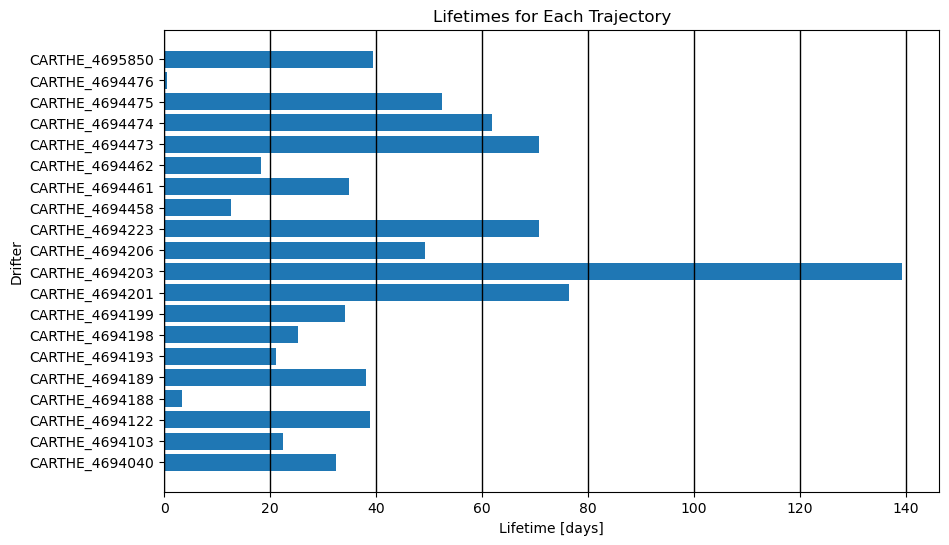

In [21]:
# Create the plot with bars showing the date ranges
plt.figure(figsize=(10, 6))

# Plot each trajectory as a horizontal bar
for ii, lifetime in enumerate(lifetimes_C_L0):
    plt.barh(trajectory_names_C_L0[ii], lifetime, color='C0', align='center') #, alpha=0.5)

# Format the x-axis to show dates properly
ax = plt.gca()

# plt.grid()
# Display grid lines for better visualization
ax.grid(True, which='major', axis='x', color='black', linestyle='-', linewidth=1)
ax.grid(True, which='minor', axis='x', color='grey', linestyle='-', linewidth=0.5)

plt.xlabel('Lifetime [days]')
plt.ylabel('Drifter')
plt.title('Lifetimes for Each Trajectory')
plt.show()

# plt.yticks(range(len(lifetimes)), [f'Trajectory {i+1}' for i in range(len(lifetimes))])


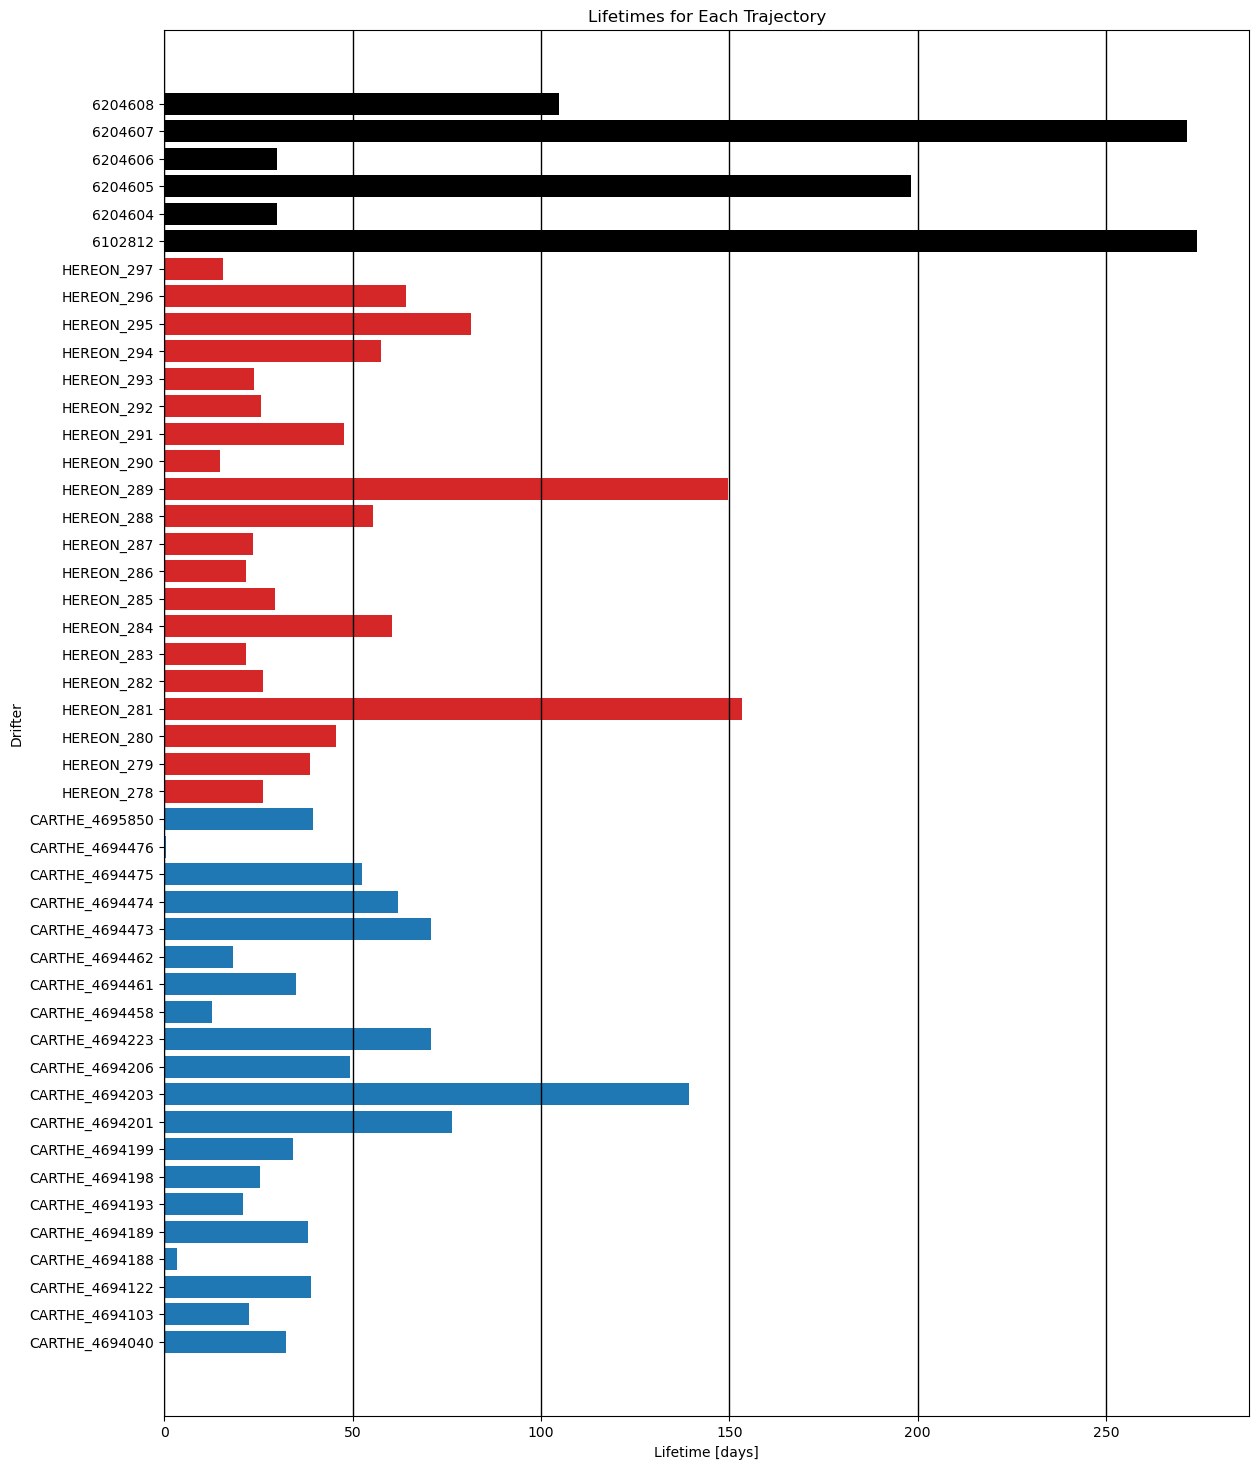

In [22]:
# Create the plot with bars showing the date ranges
plt.figure(figsize=(14, 18))

# CARTHE: Plot each trajectory as a horizontal bar
for ii, lifetime in enumerate(lifetimes_C_L0):
    plt.barh(trajectory_names_C_L0[ii], lifetime, color='C0', align='center') #, alpha=0.5)
    
# HEREON: Plot each trajectory as a horizontal bar
for ii, lifetime in enumerate(lifetimes_H_L0):
    plt.barh(trajectory_names_H_L0[ii], lifetime, color='C3', align='center') #, alpha=0.5)

# SVP-B: Plot each trajectory as a horizontal bar
for ii, lifetime in enumerate(lifetimes_S_L0):
    plt.barh(trajectory_names_S_L0[ii], lifetime, color='k', align='center') #, alpha=0.5)

# Format the x-axis to show dates properly
ax = plt.gca()

# plt.grid()
# Display grid lines for better visualization
ax.grid(True, which='major', axis='x', color='black', linestyle='-', linewidth=1)
ax.grid(True, which='minor', axis='x', color='grey', linestyle='-', linewidth=0.5)

plt.xlabel('Lifetime [days]')
plt.ylabel('Drifter')
plt.title('Lifetimes for Each Trajectory')
plt.show()


# With processed ontop:

In [23]:
myfiles_H_L1_IME = sorted(glob(filedir_proc + '*her*.nc')) 
myfiles_S_L1_IME = sorted(glob(filedir_proc + 'drifter-svpb*.nc')) 


In [24]:
lifetimes_H_L1_IME = get_trajectory_dates(myfiles_H_L1_IME)
lifetimes_S_L1_IME = get_trajectory_dates(myfiles_S_L1_IME)

In [25]:
# Extract filenames without extensions to use as trajectory names
trajectory_names_H_L1_IME = [os.path.splitext(os.path.basename(file))[0].split('-')[-1] for file in myfiles_H_L1_IME]
# trajectory_names_H_L1_IME


In [26]:
# Extract filenames without extensions to use as trajectory names
trajectory_names_S_L1_IME = [os.path.splitext(os.path.basename(file))[0].split('-')[-1] for file in myfiles_S_L1_IME]
# trajectory_names_S_L1_IME


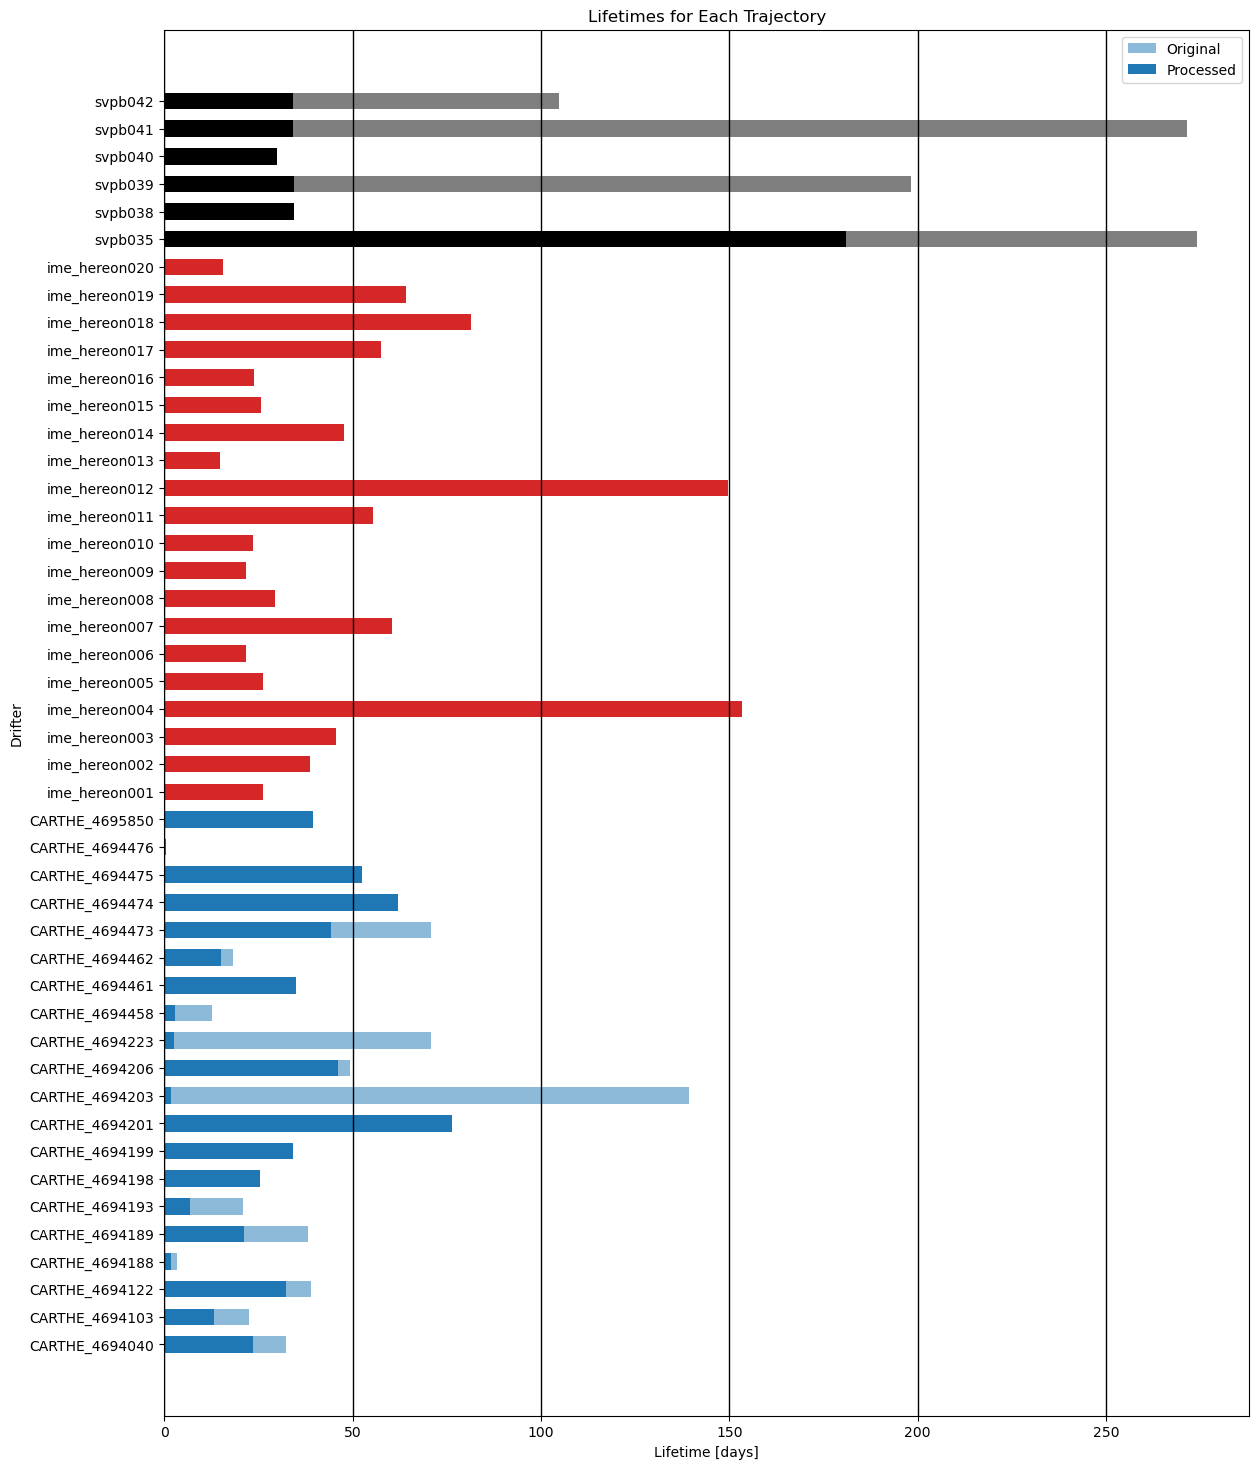

In [28]:
bar_height = 0.6

# Create the plot with bars showing the date ranges
plt.figure(figsize=(14, 18))

# CARTHE: Plot each trajectory as a horizontal bar
for ii, lifetime in enumerate(lifetimes_C_L0):
    # Original date range
    plt.barh(trajectory_names_C_L0[ii], lifetime, color='C0', align='center', alpha=0.5, height=bar_height, label='Original' if ii == 0 else "")
    # Processed date range
    plt.barh(trajectory_names_C_L0[ii], lifetimes_C_L1_IME[ii], align='center', color='C0', height=bar_height, label='Processed' if ii == 0 else "")
# , label='Processed' if i == 0 else ""

# HEREON: Plot each trajectory as a horizontal bar
for ii, lifetime in enumerate(lifetimes_H_L0):
    # Original date range
    plt.barh(trajectory_names_H_L1_IME[ii], lifetime, color='C3', align='center', alpha=0.5, height=bar_height)
    # Processed date range
    plt.barh(trajectory_names_H_L1_IME[ii], lifetimes_H_L1_IME[ii], align='center', color='C3', height=bar_height)

# SVP-B: Plot each trajectory as a horizontal bar
for ii, lifetime in enumerate(lifetimes_S_L0):
    # Original date range
    plt.barh(trajectory_names_S_L1_IME[ii], lifetime, color='k', align='center', alpha=0.5, height=bar_height)
    # Processed date range
    plt.barh(trajectory_names_S_L1_IME[ii], lifetimes_S_L1_IME[ii], align='center', color='k', height=bar_height)

# Format the x-axis to show dates properly
ax = plt.gca()

# plt.grid()
# Display grid lines for better visualization
ax.grid(True, which='major', axis='x', color='black', linestyle='-', linewidth=1)
# ax.grid(True, which='minor', axis='x', color='grey', linestyle='-', linewidth=0.5)

plt.legend()
plt.xlabel('Lifetime [days]')
plt.ylabel('Drifter')
plt.title('Lifetimes for Each Trajectory')
plt.show()

# --> Hereon nothing for processed as no trajectory cut (no 2h gaps or bigger)